In [ ]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
import warnings 
warnings.filterwarnings('ignore')

subs=pd.read_csv(r'../data/subscriptions_clean.csv')
rev=pd.read_csv(r'../data/monthly_revenue_clean.csv')

subs['signup_date'] = pd.to_datetime(subs['signup_date'])
subs['churn_date'] = pd.to_datetime(subs['churn_date'])
rev['month'] = pd.to_datetime(rev['month'])

print(f"Subscriptions : {subs.shape}")
print(f"Revenue       : {rev.shape}")
print(f"\nChurn rate: {subs['churned_binary'].mean()*100:.2f}%")




Subscriptions : (600, 24)
Revenue       : (48, 8)

Churn rate: 52.17%


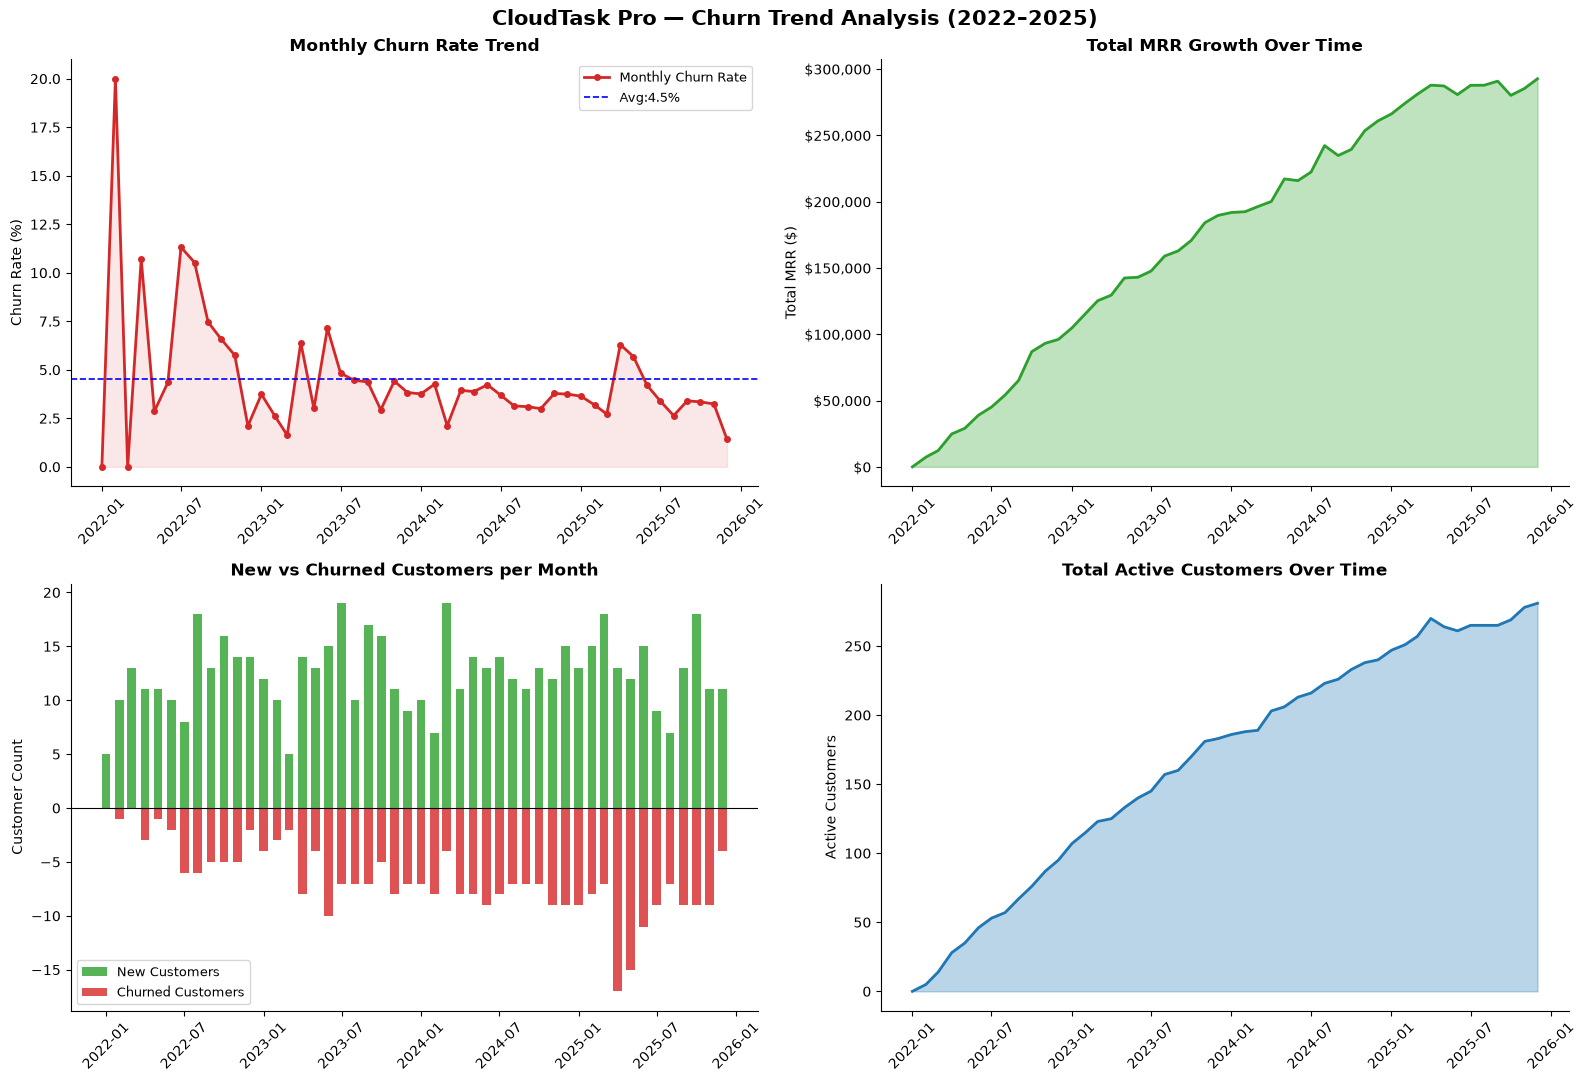

=== CHURN TREND SUMMARY ===
Avg monthly churn rate : 4.52%
Max monthly churn rate : 20.00%
Min monthly churn rate : 0.00%

Month with highest churn:
month                     2022-02-01 00:00:00
monthly_churn_rate_pct                   20.0
churned_customers                           1
Name: 1, dtype: object

Peak MRR: $292,628.61
Peak month: 2025-12

Latest MRR  : $292,628.61
Latest active customers: 281

=== YEAR OVER YEAR SUMMARY ===
 year  avg_churn_rate  total_churned  total_new       avg_mrr
 2022        6.805833             36        143  46081.155000
 2023        4.115833             72        151 147849.401667
 2024        3.555000             91        151 222196.104167
 2025        3.599167            114        155 283426.995000


In [12]:
fig,axes=plt.subplots(2,2,figsize=(16,11))
fig.suptitle('CloudTask Pro — Churn Trend Analysis (2022–2025)',fontsize=15, fontweight='bold')

axes[0,0].plot(rev['month'],rev['monthly_churn_rate_pct'],color="#d62728",linewidth=2,marker="o",markersize=4,label='Monthly Churn Rate')
axes[0,0].axhline(rev['monthly_churn_rate_pct'].mean(),color='blue',linestyle='--',linewidth=1.2,label=f"Avg:{rev['monthly_churn_rate_pct'].mean():.1f}%")
axes[0,0].fill_between(rev['month'],rev['monthly_churn_rate_pct'],alpha=0.1, color='#d62728')
axes[0,0].set_title('Monthly Churn Rate Trend', fontweight='bold')

axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend(fontsize=9)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)

axes[0,1].fill_between(rev['month'],rev['total_mrr'],alpha=0.3,color='#2ca02c')
axes[0,1].plot(rev['month'],rev['total_mrr'],color='#2ca02c',linewidth=2)
axes[0,1].set_title('Total MRR Growth Over Time', fontweight='bold')
axes[0,1].set_ylabel('Total MRR ($)')
axes[0,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)

# new vs Churned Customers rate per month
axes[1,0].bar(rev['month'], rev['new_customers'],
               label='New Customers', color='#2ca02c',
               alpha=0.8, width=20)
axes[1,0].bar(rev['month'], -rev['churned_customers'],
               label='Churned Customers', color='#d62728',
               alpha=0.8, width=20)
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_title('New vs Churned Customers per Month',
                     fontweight='bold')
axes[1,0].set_ylabel('Customer Count')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(fontsize=9)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)

# Active Customers Growth
axes[1,1].fill_between(rev['month'],
                        rev['total_active_customers'],
                        alpha=0.3, color='#1f77b4')
axes[1,1].plot(rev['month'], rev['total_active_customers'],
               color='#1f77b4', linewidth=2)
axes[1,1].set_title('Total Active Customers Over Time',
                     fontweight='bold')
axes[1,1].set_ylabel('Active Customers')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/chart1_churn_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()



print("=== CHURN TREND SUMMARY ===")
print(f"Avg monthly churn rate : {rev['monthly_churn_rate_pct'].mean():.2f}%")
print(f"Max monthly churn rate : {rev['monthly_churn_rate_pct'].max():.2f}%")
print(f"Min monthly churn rate : {rev['monthly_churn_rate_pct'].min():.2f}%")
print(f"\nMonth with highest churn:")
print(rev.loc[rev['monthly_churn_rate_pct'].idxmax(),
              ['month', 'monthly_churn_rate_pct',
               'churned_customers']])
print(f"\nPeak MRR: ${rev['total_mrr'].max():,.2f}")
print(f"Peak month: {rev.loc[rev['total_mrr'].idxmax(), 'month'].strftime('%Y-%m')}")
print(f"\nLatest MRR  : ${rev['total_mrr'].iloc[-1]:,.2f}")
print(f"Latest active customers: {rev['total_active_customers'].iloc[-1]}")

# ── Year over year churn trend ──
rev['year'] = rev['month'].dt.year
yearly = rev.groupby('year').agg(
    avg_churn_rate=('monthly_churn_rate_pct', 'mean'),
    total_churned=('churned_customers', 'sum'),
    total_new=('new_customers', 'sum'),
    avg_mrr=('total_mrr', 'mean')
).reset_index()

print("\n=== YEAR OVER YEAR SUMMARY ===")
print(yearly.to_string(index=False))

### 📊 Chart 1 — Churn Trend Insight

**Year over Year Churn Rate:**
| Year | Avg Monthly Churn | Total Churned | Trend |
|---|---|---|---|
| 2022 | 6.81% | 36 | 🔴 High — early stage |
| 2023 | 4.12% | 72 | 🟠 Improving |
| 2024 | 3.56% | 91 | 🟢 Best rate |
| 2025 | 3.60% | 114 | 🟠 Stable but volume rising |

**Key Findings:**
- Monthly churn rate improved 48% from 2022 to 2024 —
  retention efforts are working on a rate basis
- But absolute churned customers grew 3x (36 → 114) as
  the customer base scaled — churn volume is a growing problem
- MRR grew 6x from $46K to $283K avg — acquisition is
  outpacing churn but the gap is narrowing
- Active customers plateaued at ~270 in mid-2025 — the company
  is now on a growth treadmill: acquiring just enough to
  replace churned customers
- Overall cumulative churn rate: 52.17% — critically high

**Is churn improving?**
Rate: Yes ✅ | Volume: No ❌ | The company needs both to improve
to achieve sustainable growth.

In [15]:
# Churn By plan

plan_analysis=subs.groupby('plan').agg(
    total_customers=('customer_id','count'),
    churned=('churned_binary','sum'),
    avg_mrr=('monthly_revenue','mean'),
    avg_lifespan=('lifespan_months','mean'),
    avg_clv=('clv','mean'),
    avg_nps=('nps_score','mean'),
    avg_feature_usage=('feature_usage_pct','mean'),
    upgrade_rate=('upgraded_binary','mean')

).reset_index()
plan_analysis['churn_rate_%'] = (
    plan_analysis['churned'] / plan_analysis['total_customers'] * 100
).round(2)
plan_analysis['retention_rate_%'] = (
100 - plan_analysis['churn_rate_%']
).round(2)
plan_analysis = plan_analysis.sort_values('churn_rate_%', ascending=False)

print("=== CHURN BY PLAN ===")
print(plan_analysis[['plan', 'total_customers', 'churned','churn_rate_%', 'avg_mrr', 'avg_lifespan','avg_clv', 'avg_nps','avg_feature_usage']].to_string(index=False))


#  Churn by billing cycle :
billing_analysis = subs.groupby('billing_cycle').agg(
    total_customers=('customer_id', 'count'),
    churned=('churned_binary', 'sum'),
    avg_mrr=('monthly_revenue', 'mean'),
    avg_lifespan=('lifespan_months', 'mean'),
    avg_clv=('clv', 'mean')
).reset_index()

billing_analysis['churn_rate_%'] = (
    billing_analysis['churned'] /
    billing_analysis['total_customers'] * 100
).round(2)

print("\n=== CHURN BY BILLING CYCLE ===")
print(billing_analysis.to_string(index=False))


# Plan x Billing cycle cross 
cross = subs.groupby(['plan', 'billing_cycle']).agg(
    total=('customer_id', 'count'),
    churned=('churned_binary', 'sum')
).reset_index()
cross['churn_rate_%'] = (
    cross['churned'] / cross['total'] * 100
).round(2)
cross = cross.sort_values(['plan', 'churn_rate_%'], ascending=[True, False])

print("\n=== PLAN x BILLING CYCLE CROSS ===")
print(cross.to_string(index=False))



=== CHURN BY PLAN ===
        plan  total_customers  churned  churn_rate_%     avg_mrr  avg_lifespan      avg_clv  avg_nps  avg_feature_usage
     Starter              217      153         70.51  215.543594      8.313825  1852.262949 3.788018          35.497696
Professional              173       83         47.98  497.041272     14.541618  8020.466185 4.450867          42.306358
    Business              160       66         41.25 1303.636438     16.951250 21592.303187 4.962500          43.881250
  Enterprise               50       11         22.00 2984.993000     22.744000 65751.275400 4.660000          46.800000

=== CHURN BY BILLING CYCLE ===
billing_cycle  total_customers  churned    avg_mrr  avg_lifespan      avg_clv  churn_rate_%
       Annual              248      100 740.558589     15.097177 11928.218790         40.32
      Monthly              352      213 871.971733     12.571307 15834.135597         60.51

=== PLAN x BILLING CYCLE CROSS ===
        plan billing_cycle  total 

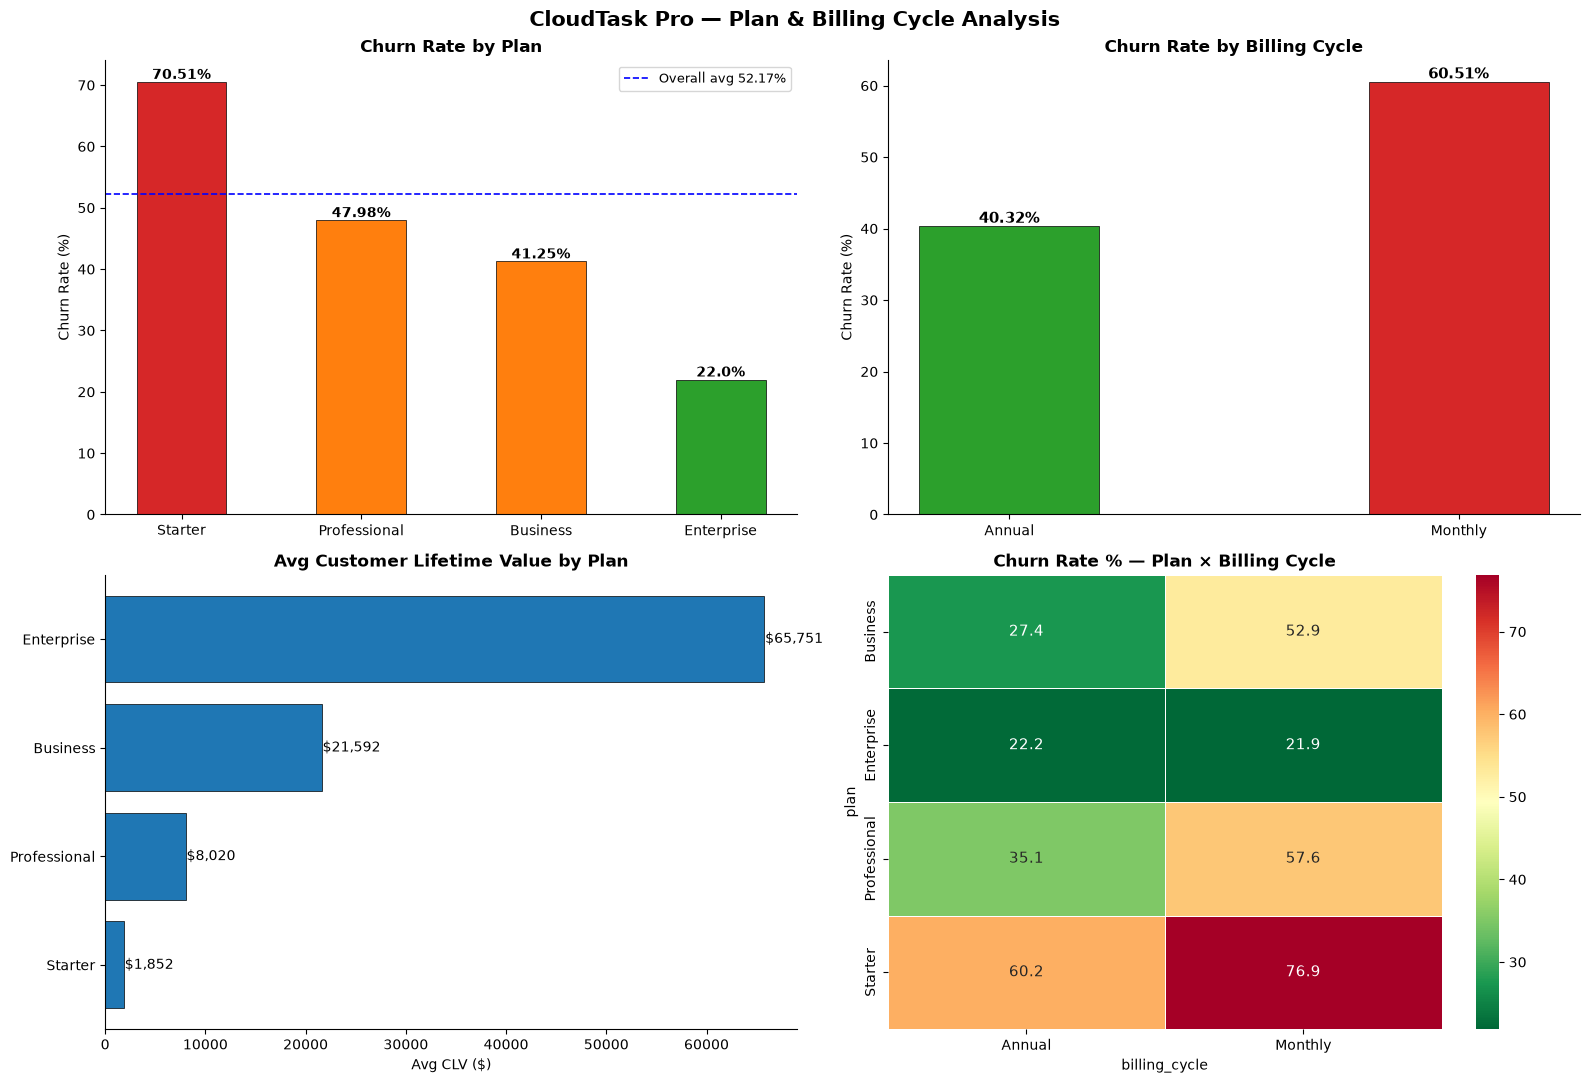

In [23]:
fig,axes=plt.subplots(2,2,figsize=(16,11))

fig.suptitle('CloudTask Pro — Plan & Billing Cycle Analysis', fontsize=15, fontweight='bold')
colors = ['#d62728' if x > 50 else '#ff7f0e' if x > 30
          else '#2ca02c' for x in plan_analysis['churn_rate_%']]

bars = axes[0,0].bar(plan_analysis['plan'],
                      plan_analysis['churn_rate_%'],
                      color=colors, edgecolor='black',
                      linewidth=0.5, width=0.5)
axes[0,0].axhline(subs['churned_binary'].mean()*100,
                   color='blue', linestyle='--',
                   linewidth=1.2, label='Overall avg 52.17%')
for bar, val in zip(bars, plan_analysis['churn_rate_%']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'{val}%', ha='center', fontsize=10,
                   fontweight='bold')
axes[0,0].set_title('Churn Rate by Plan', fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].legend(fontsize=9)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)


colors2 = ['#d62728' if x > 50 else '#2ca02c'
           for x in billing_analysis['churn_rate_%']]
bars2 = axes[0,1].bar(billing_analysis['billing_cycle'],
                       billing_analysis['churn_rate_%'],
                       color=colors2, edgecolor='black',
                       linewidth=0.5, width=0.4)
for bar, val in zip(bars2, billing_analysis['churn_rate_%']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'{val}%', ha='center', fontsize=11,
                   fontweight='bold')
axes[0,1].set_title('Churn Rate by Billing Cycle', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)


plan_clv = plan_analysis.sort_values('avg_clv', ascending=True)
bars3 = axes[1,0].barh(plan_clv['plan'], plan_clv['avg_clv'],
                        color='#1f77b4', edgecolor='black',
                        linewidth=0.5)
for bar, val in zip(bars3, plan_clv['avg_clv']):
    axes[1,0].text(val + 100, bar.get_y() + bar.get_height()/2,
                   f'${val:,.0f}', va='center', fontsize=10)
axes[1,0].set_title('Avg Customer Lifetime Value by Plan',
                     fontweight='bold')
axes[1,0].set_xlabel('Avg CLV ($)')
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)

heatmap_data = cross.pivot(index='plan',
                            columns='billing_cycle',
                            values='churn_rate_%')
sns.heatmap(heatmap_data, annot=True, fmt='.1f',
            cmap='RdYlGn_r', ax=axes[1,1],
            linewidths=0.5, annot_kws={'size': 11})
axes[1,1].set_title('Churn Rate % — Plan × Billing Cycle',
                     fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/chart2_plan_billing_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 📊 Chart 2 — Plan & Billing Cycle Insight

**Churn by Plan:**
| Plan | Churn Rate | Avg CLV | Risk Level |
|---|---|---|---|
| Starter | 70.51% | $1,852 | 🔴 Critical |
| Professional | 47.98% | $8,020 | 🔴 High |
| Business | 41.25% | $21,592 | 🟠 Elevated |
| Enterprise | 22.00% | $65,751 | 🟢 Healthy |

**Billing Cycle Impact:**
- Annual customers churn at 40.32% vs Monthly at 60.51%
- Annual billing reduces churn by 20 percentage points
- Biggest danger zone: Starter Monthly = 76.87% churn
- Safest combination: Enterprise Annual = 22.22% churn

**Key Findings:**
- Enterprise CLV ($65,751) is 35x higher than Starter ($1,852)
- Annual billing is the single most impactful retention lever —
  reduces churn by 33% across all plans
- Starter customers have lowest NPS (3.79) and lowest feature
  usage (35.5%) — they never experience product value
- Business Annual (27.4% churn) performs nearly as well as
  Enterprise — billing cycle matters more than plan level
  at higher tiers

**Recommendation:**
- Offer annual billing discount (10-15%) to convert monthly
  customers — immediate retention improvement
- Redesign Starter onboarding to drive feature adoption above
  the 30% at-risk threshold
- Invest in Enterprise acquisition — 22% churn + $65,751 CLV
  makes Enterprise the most profitable segment by far

In [26]:
# Churn  reasons analysis 
churned_only=subs[subs['churned']=='Yes'].copy()
reason_overall=churned_only['churn_reason'].value_counts().reset_index()

reason_overall.columns=['churn_reason','count']
reason_overall['pct']=(
    reason_overall['count']/len(churned_only)*100
).round(2)
print("=== CHURN REASONS OVERALL ===")
print(reason_overall.to_string(index=False))

reason_plan = churned_only.groupby(
    ['plan', 'churn_reason']
).size().reset_index(name='count')

reason_plan['pct'] = (
    reason_plan.groupby('plan')['count']
    .transform(lambda x: x / x.sum() * 100)
).round(2)

reason_plan = reason_plan.sort_values(['plan', 'count'],
                                       ascending=[True, False])

print("\n=== CHURN REASONS BY PLAN ===")
print(reason_plan.to_string(index=False))

reason_size = churned_only.groupby(
    ['company_size', 'churn_reason']
).size().reset_index(name='count')

reason_size['pct'] = (
    reason_size.groupby('company_size')['count']
    .transform(lambda x: x / x.sum() * 100)
).round(2)

reason_size = reason_size.sort_values(
    ['company_size', 'count'], ascending=[True, False]
)

print("\n=== TOP CHURN REASON BY COMPANY SIZE ===")
top_reason_size = reason_size.loc[
    reason_size.groupby('company_size')['count'].idxmax()
]
print(top_reason_size.to_string(index=False))

=== CHURN REASONS OVERALL ===
       churn_reason  count   pct
        Budget Cuts     53 16.93
     Price Too High     51 16.29
     Company Closed     48 15.34
       Poor Support     42 13.42
   No Longer Needed     41 13.10
   Missing Features     40 12.78
Switched Competitor     38 12.14

=== CHURN REASONS BY PLAN ===
        plan        churn_reason  count   pct
    Business    Missing Features     12 18.18
    Business    No Longer Needed     11 16.67
    Business        Poor Support     11 16.67
    Business         Budget Cuts     10 15.15
    Business      Company Closed      8 12.12
    Business      Price Too High      7 10.61
    Business Switched Competitor      7 10.61
  Enterprise      Company Closed      3 27.27
  Enterprise    No Longer Needed      3 27.27
  Enterprise Switched Competitor      2 18.18
  Enterprise    Missing Features      1  9.09
  Enterprise        Poor Support      1  9.09
  Enterprise      Price Too High      1  9.09
Professional         Budget Cut

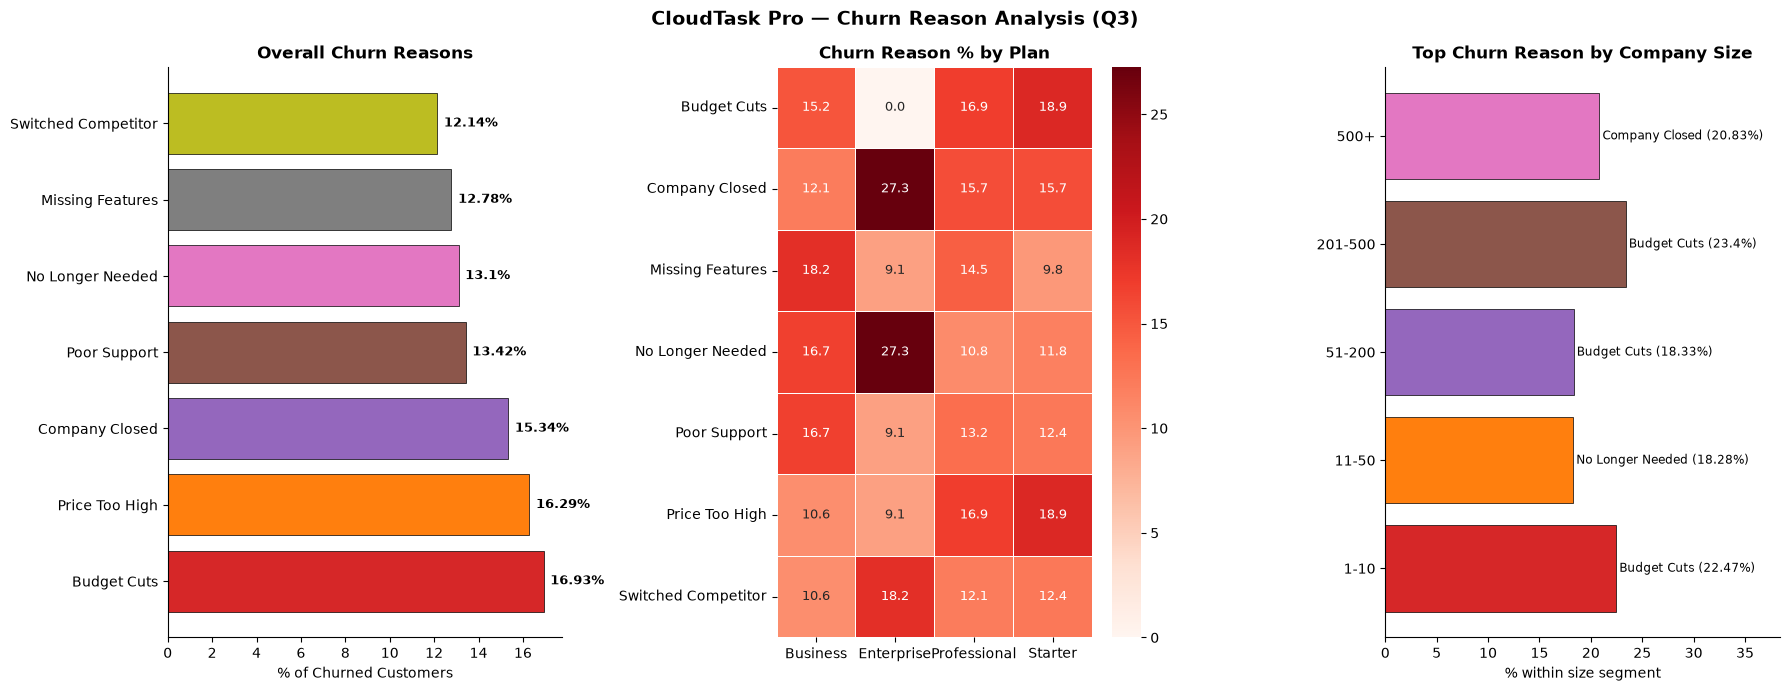

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('CloudTask Pro — Churn Reason Analysis (Q3)',
             fontsize=14, fontweight='bold')

# ── Panel 1: Overall Churn Reasons ──
colors = ['#d62728', '#ff7f0e', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']

bars = axes[0].barh(reason_overall['churn_reason'],
                     reason_overall['pct'],
                     color=colors[:len(reason_overall)],
                     edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, reason_overall['pct']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=9,
                 fontweight='bold')
axes[0].set_title('Overall Churn Reasons', fontweight='bold')
axes[0].set_xlabel('% of Churned Customers')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Panel 2: Top Churn Reason by Plan (heatmap) ──
reason_pivot = reason_plan.pivot(index='churn_reason',
                                  columns='plan',
                                  values='pct').fillna(0)

sns.heatmap(reason_pivot, annot=True, fmt='.1f',
            cmap='Reds', ax=axes[1],
            linewidths=0.5, annot_kws={'size': 9})
axes[1].set_title('Churn Reason % by Plan', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# ── Panel 3: Top Reason by Company Size ──
size_order = ['1-10', '11-50', '51-200', '201-500', '500+']
top_reason_size_sorted = top_reason_size.set_index(
    'company_size'
).reindex(size_order).reset_index()

bar_colors = ['#d62728', '#ff7f0e', '#9467bd',
              '#8c564b', '#e377c2']
bars3 = axes[2].barh(
    top_reason_size_sorted['company_size'],
    top_reason_size_sorted['pct'],
    color=bar_colors, edgecolor='black', linewidth=0.5
)

for bar, reason, val in zip(
    bars3,
    top_reason_size_sorted['churn_reason'],
    top_reason_size_sorted['pct']
):
    axes[2].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{reason} ({val}%)',
        va='center', fontsize=8.5
    )

axes[2].set_title('Top Churn Reason by Company Size',
                   fontweight='bold')
axes[2].set_xlabel('% within size segment')
axes[2].set_xlim(0, top_reason_size_sorted['pct'].max() + 15)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/chart3_churn_reasons.png',
            dpi=150, bbox_inches='tight')
plt.show()